In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    "../data/processed/cleaned_transactions.csv"
)

df["date"] = pd.to_datetime(df["date"])

print("Dataset loaded:", df.shape)

Dataset loaded: (100000, 17)


In [2]:
total_revenue = df["revenue"].sum()
total_profit = df["profit"].sum()
total_orders = len(df)
total_units = df["units_sold"].sum()
avg_order_value = df["revenue"].mean()

print("===== BUSINESS KPIs =====")
print(f"Total Revenue: ₹{total_revenue:,.2f}")
print(f"Total Profit: ₹{total_profit:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Units Sold: {total_units:,}")
print(f"Average Order Value: ₹{avg_order_value:,.2f}")

===== BUSINESS KPIs =====
Total Revenue: ₹259,435,520.00
Total Profit: ₹89,840,984.13
Total Orders: 100,000
Total Units Sold: 295,780
Average Order Value: ₹2,594.36


In [3]:
monthly_revenue = (
    df.groupby(df["date"].dt.to_period("M"))["revenue"]
    .sum()
)

print(monthly_revenue)

date
2026-01    44471037.5
2026-02    40531175.0
2026-03    44891375.0
2026-04    45007662.5
2026-05    43203505.0
2026-06    41330765.0
Freq: M, Name: revenue, dtype: float64


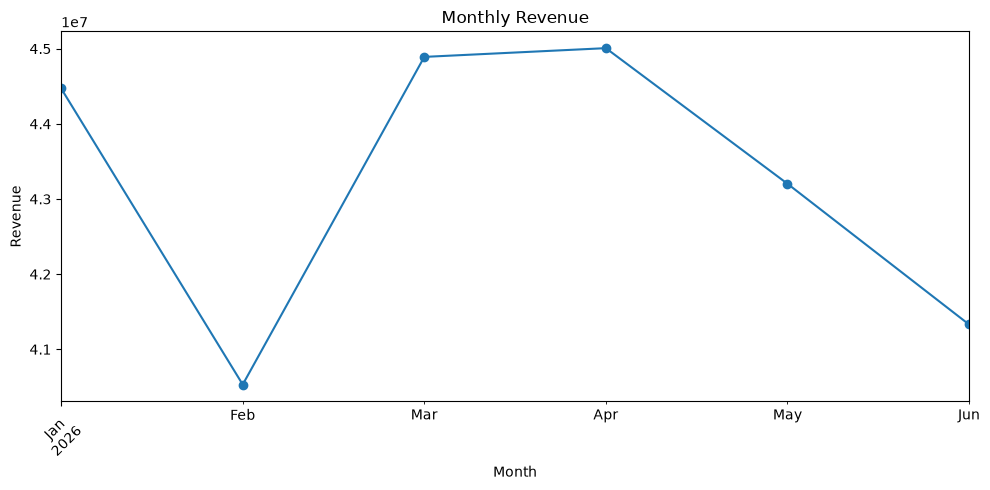

In [4]:
monthly_revenue.plot(
    kind="line",
    marker="o",
    figsize=(10, 5)
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
region_revenue = (
    df.groupby("region")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

print(region_revenue)

region
South    79469985.0
North    66065850.0
West     61580160.0
East     52319525.0
Name: revenue, dtype: float64


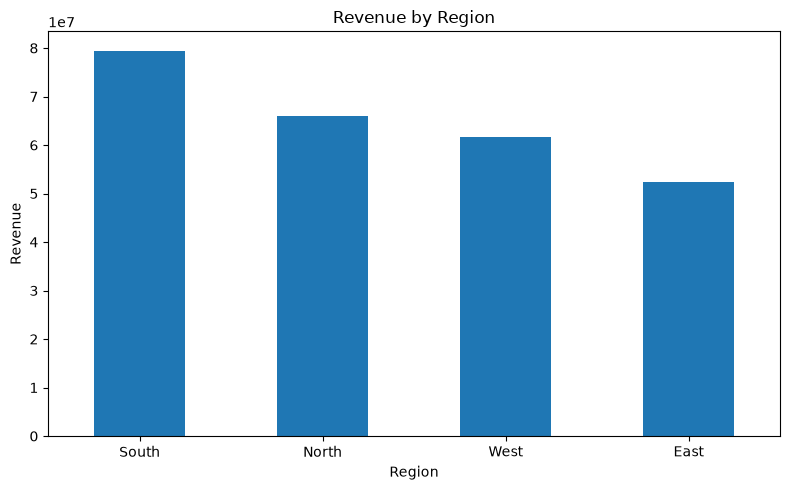

In [6]:
region_revenue.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [7]:
# Monthly revenue and month-over-month change

monthly_revenue = (
    df.groupby(df["date"].dt.to_period("M"))["revenue"]
    .sum()
)

monthly_change = monthly_revenue.pct_change() * 100

revenue_analysis = pd.DataFrame({
    "Revenue": monthly_revenue,
    "MoM_Change_%": monthly_change
})

revenue_analysis

,Revenue,MoM_Change_%
date,,
2026-01,44471037.5,NaN
2026-02,40531175.0,-8.859390
2026-03,44891375.0,10.757645
2026-04,45007662.5,0.259042
2026-05,43203505.0,-4.008556
2026-06,41330765.0,-4.334695


In [8]:
worst_month = monthly_change.idxmin()
worst_change = monthly_change.min()

print("Largest revenue decline:")
print("Month:", worst_month)
print("Change:", round(worst_change, 2), "%")

Largest revenue decline:
Month: 2026-02
Change: -8.86 %


In [9]:
region_monthly = (
    df.groupby([
        df["date"].dt.to_period("M"),
        "region"
    ])["revenue"]
    .sum()
    .unstack()
)

region_monthly

region,East,North,South,West
date,,,,
2026-01,8720250.0,11158462.5,13302150.0,11290175.0
2026-02,8288437.5,9644425.0,12580237.5,10018075.0
2026-03,8915187.5,11736137.5,13190387.5,11049662.5
2026-04,8727632.5,11288827.5,13652795.0,11338407.5
2026-05,9071715.0,11312530.0,13671617.5,9147642.5
2026-06,8596302.5,10925467.5,13072797.5,8736197.5


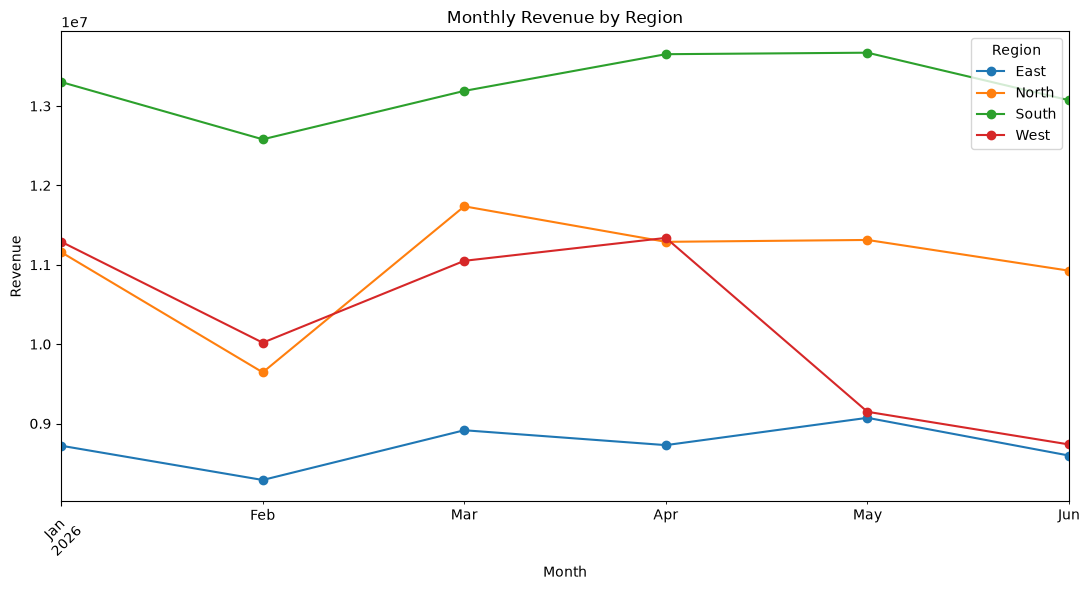

In [10]:
region_monthly.plot(
    kind="line",
    marker="o",
    figsize=(11, 6)
)

plt.title("Monthly Revenue by Region")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend(title="Region")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
product_monthly = (
    df.groupby([
        df["date"].dt.to_period("M"),
        "product"
    ])["revenue"]
    .sum()
    .unstack()
)

product_monthly

product,Product A,Product B,Product C,Product D,Product E
date,,,,,
2026-01,5782975.0,6790725.0,9471200.0,11914812.5,10511325.0
2026-02,5474300.0,6336412.5,8626700.0,10429562.5,9664200.0
2026-03,6058025.0,6774487.5,9174150.0,11889187.5,10995525.0
2026-04,5648575.0,7951950.0,8844050.0,11723937.5,10839150.0
2026-05,5464575.0,8129880.0,8797400.0,11054000.0,9757650.0
2026-06,5367825.0,7888590.0,8279300.0,10343250.0,9451800.0


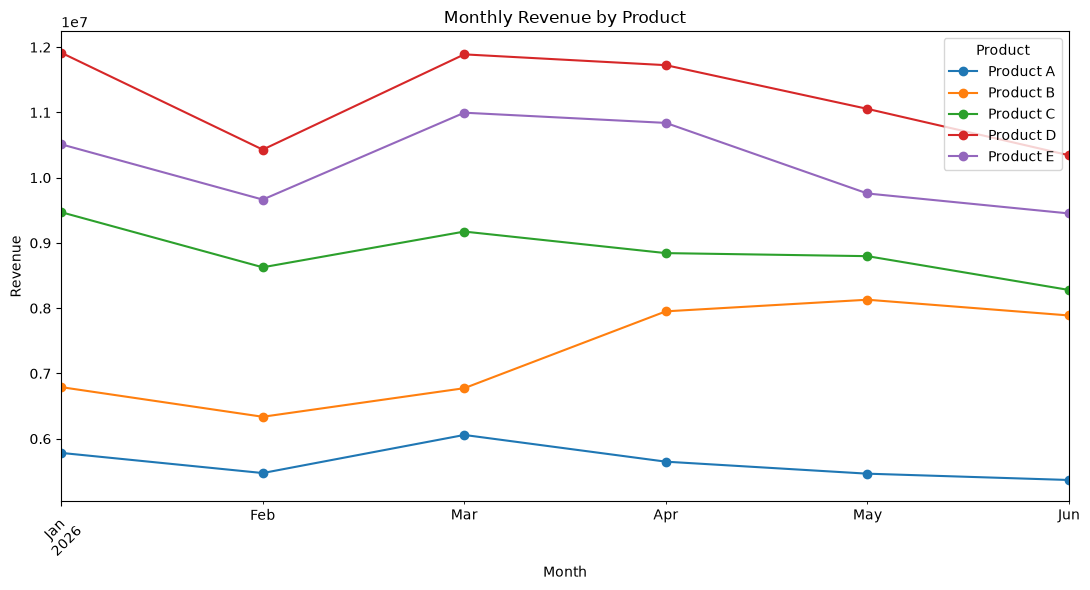

In [12]:
product_monthly.plot(
    kind="line",
    marker="o",
    figsize=(11, 6)
)

plt.title("Monthly Revenue by Product")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend(title="Product")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
channel_monthly = (
    df.groupby([
        df["date"].dt.to_period("M"),
        "marketing_channel"
    ])["revenue"]
    .sum()
    .unstack()
)

channel_monthly

marketing_channel,Direct,Email,Referral,Search,Social Media
date,,,,,
2026-01,8843750.0,6846900.0,6568125.0,13351237.5,8861025.0
2026-02,8447787.5,5977125.0,6035000.0,11964937.5,8106325.0
2026-03,8982900.0,6593125.0,6659100.0,13518437.5,9137812.5
2026-04,9171925.0,7042682.5,6945825.0,13137502.5,8709727.5
2026-05,8606460.0,6363735.0,6436480.0,13142075.0,8654755.0
2026-06,8189200.0,6139212.5,5989615.0,12635820.0,8376917.5


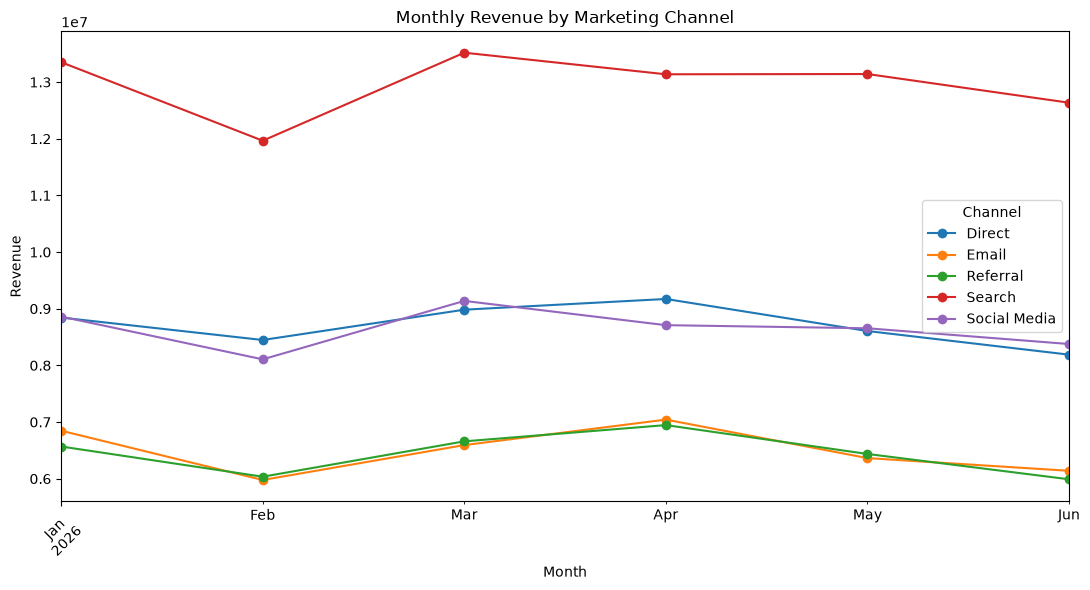

In [14]:
channel_monthly.plot(
    kind="line",
    marker="o",
    figsize=(11, 6)
)

plt.title("Monthly Revenue by Marketing Channel")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend(title="Channel")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
monthly_revenue = (
    df.groupby(df["date"].dt.to_period("M"))["revenue"]
    .sum()
)

monthly_change = monthly_revenue.pct_change() * 100

revenue_analysis = pd.DataFrame({
    "Revenue": monthly_revenue,
    "MoM_Change_%": monthly_change.round(2)
})

revenue_analysis

,Revenue,MoM_Change_%
date,,
2026-01,44471037.5,NaN
2026-02,40531175.0,-8.86
2026-03,44891375.0,10.76
2026-04,45007662.5,0.26
2026-05,43203505.0,-4.01
2026-06,41330765.0,-4.33


In [17]:
monthly_revenue = (
    df.groupby(df["date"].dt.to_period("M"))["revenue"]
    .sum()
)

monthly_change = monthly_revenue.pct_change() * 100

revenue_analysis = pd.DataFrame({
    "Revenue": monthly_revenue,
    "MoM_Change_%": monthly_change.round(2)
})

revenue_analysis

,Revenue,MoM_Change_%
date,,
2026-01,44471037.5,NaN
2026-02,40531175.0,-8.86
2026-03,44891375.0,10.76
2026-04,45007662.5,0.26
2026-05,43203505.0,-4.01
2026-06,41330765.0,-4.33


In [18]:
may_region = (
    df[df["date"].dt.month == 5]
    .groupby("region")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

may_region

region
South    13671617.5
North    11312530.0
West      9147642.5
East      9071715.0
Name: revenue, dtype: float64

In [19]:
april_region = (
    df[df["date"].dt.month == 4]
    .groupby("region")["revenue"]
    .sum()
)

region_change = (
    ((may_region - april_region) / april_region) * 100
).sort_values()

region_change

region
West    -19.321629
South     0.137866
North     0.209964
East      3.942449
Name: revenue, dtype: float64

In [20]:
product_revenue = (
    df.groupby([
        df["date"].dt.to_period("M"),
        "product"
    ])["revenue"]
    .sum()
    .unstack()
)

product_revenue

product,Product A,Product B,Product C,Product D,Product E
date,,,,,
2026-01,5782975.0,6790725.0,9471200.0,11914812.5,10511325.0
2026-02,5474300.0,6336412.5,8626700.0,10429562.5,9664200.0
2026-03,6058025.0,6774487.5,9174150.0,11889187.5,10995525.0
2026-04,5648575.0,7951950.0,8844050.0,11723937.5,10839150.0
2026-05,5464575.0,8129880.0,8797400.0,11054000.0,9757650.0
2026-06,5367825.0,7888590.0,8279300.0,10343250.0,9451800.0


In [21]:
product_change = product_revenue.pct_change() * 100

product_change

product,Product A,Product B,Product C,Product D,Product E
date,,,,,
2026-01,NaN,NaN,NaN,NaN,NaN
2026-02,-5.337651,-6.690191,-8.916505,-12.465576,-8.059165
2026-03,10.663007,6.913612,6.345996,13.995074,13.775843
2026-04,-6.758803,17.380835,-3.598154,-1.389918,-1.422169
2026-05,-3.257459,2.237564,-0.527473,-5.714270,-9.977720
2026-06,-1.770495,-2.967940,-5.889240,-6.429799,-3.134464


In [22]:
social = df[
    df["marketing_channel"] == "Social Media"
]

social_spend = (
    social.groupby(
        social["date"].dt.to_period("M")
    )["marketing_spend"]
    .sum()
)

social_spend

date
2026-01    345781.511608
2026-02    314020.398266
2026-03    346566.095405
2026-04    334963.449061
2026-05    339568.112691
2026-06    197466.842104
Freq: M, Name: marketing_spend, dtype: float64